## Función General: ¿Para qué Sirve un Árbol?

La función principal de un Árbol de Decisión es **clasificar (o predecir)**.

Piénsalo como un sistema automático para tomar decisiones. Es un modelo de **"caja blanca" (white box)** porque, a diferencia de otros modelos complejos, podemos ver *exactamente* cómo llega a una conclusión.

> **En la vida real:** Es como un diagrama de flujo que un médico de urgencias podría seguir:
> * ¿El paciente tiene fiebre?
> * (Si SÍ) -> ¿Tiene tos?
> * (Si NO) -> ¿Tiene dolor abdominal?

> **En nuestro caso:** Es un "botánico experto" que has entrenado. Cuando le das una flor nueva, le hace una serie de preguntas (midiendo sus pétalos y sépalos) hasta que puede decir con confianza: "¡Esto es una Virginica!".

Su objetivo es tomar un conjunto de datos desordenados y encontrar la forma más eficiente de separarlos en sus clases correctas.

---


## El Proceso del Árbol: ¿Cómo "Aprende" y "Decide"?

El proceso tiene dos fases: **Entrenamiento** (cuando "aprende" y se construye) y **Predicción** (cuando "decide" sobre datos nuevos).

### Fase 1: El Entrenamiento (Construcción del Árbol)

Aquí es donde ocurre la "magia". El árbol se construye de arriba hacia abajo (desde la raíz).

Imagina que tienes tus 120 flores de entrenamiento en una gran habitación, todas mezcladas (`[40 Setosa, 40 Versicolor, 40 Virginica]`).

1.  **La Búsqueda de la "Mejor Pregunta":**
    El algoritmo no elige una pregunta al azar. Prueba *todas* las preguntas posibles en *todas* las características (ej. "¿largo pétalo <= 1.0?", "¿largo pétalo <= 1.1?", "¿ancho sépalo <= 3.0?").

2.  **El Criterio: "Pureza" (Gini):**
    ¿Cómo sabe cuál es la "mejor" pregunta? Busca la pregunta que cree la "mayor ganancia de información" o, más fácil, la que genere los grupos más **"puros"**.

    

    * Un grupo **"puro"** (Gini = 0.0) es uno donde todas las muestras son de la misma clase (ej. `[40 Setosa, 0 Versicolor, 0 Virginica]`).
    * Un grupo **"impuro"** (Gini alto) es uno donde todo está mezclado (ej. `[40, 40, 40]`).

    En nuestro caso, la "mejor" pregunta fue: **largo pétalo <= 2.45**. ¿Por qué? Porque esa simple pregunta separa perfectamente a todas las Setosas del resto. Es la división más "limpia" que podía hacer.

3.  **Recursión (Repetir el Proceso):**
    Ahora tiene dos grupos nuevos. El algoritmo repite el Proceso 1 y 2 en cada uno de estos nuevos grupos.
    * **Grupo 1 (True):** `[40 Setosa, 0, 0]`. El Gini es 0.0. Es un grupo puro. ¡No hay más preguntas que hacer! Se convierte en un **Nodo Hoja (Leaf)**.
    * **Grupo 2 (False):** `[0 Setosa, 40 Versicolor, 40 Virginica]`. Este grupo todavía está mezclado. El algoritmo busca la siguiente mejor pregunta (que resultó ser `ancho pétalo <= 1.75`) y vuelve a dividir.

4.  **Parada:**
    Este proceso se repite hasta que:
    * a) Todos los nodos son "puros".
    * b) Se queda sin preguntas que hacer.
    * c) Le decimos que pare (ej. `max_depth=3`).

### Fase 2: La Predicción (Toma de Decisión)

Esta fase es mucho más simple:

1.  Una flor nueva (con sus 4 medidas) entra por el **Nodo Raíz** (la caja de arriba).
2.  Responde la pregunta del nodo (Verdadero o Falso).
3.  Sigue la flecha correspondiente (izquierda para Verdadero, derecha para Falso).
4.  Repite el proceso en cada nodo que visita.
5.  Continúa bajando hasta que aterriza en un **Nodo Hoja** (un nodo sin más preguntas).
6.  La clase de ese Nodo Hoja (ej. `class = Virginica`) es la **predicción final** del modelo.

---

## Paso 1: Importar las Bibliotecas

Primero, importamos todas las bibliotecas que necesitaremos:

* `pandas`: Para manejar nuestros datos en un DataFrame.
* `load_iris`: Para cargar el conjunto de datos de ejemplo.
* `DecisionTreeClassifier`: ¡Este es nuestro algoritmo!
* `train_test_split`: Para dividir nuestros datos en entrenamiento y prueba.
* `metrics` (accuracy, report, matrix): Para evaluar qué tan bueno es nuestro modelo.
* `plot_tree`: ¡La herramienta clave para visualizar nuestro árbol!

In [ ]:
# Importación de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Componentes de Scikit-learn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier # <--- Libreria de arboles
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree # <--- Para visualizar el árbol

# Configuración para que los gráficos se vean más grandes
plt.rcParams['figure.figsize'] = (12, 8)

## Paso 2: Cargar y Preparar los Datos

Cargamos el dataset "Iris" y lo convertimos a un DataFrame de pandas. Esto nos permite explorar los datos fácilmente. Añadiremos columnas con los nombres de las características y las especies para que sea más legible.

In [ ]:
# Cargar el dataset
iris = load_iris()

# Convertir a DataFrame de Pandas
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Mapear los números del target (0, 1, 2) a los nombres reales
target_names_map = {0:'setosa', 1:'versicolor', 2:'virginica'}
df['species_name'] = df['species'].map(target_names_map)

# Echemos un vistazo a los datos
print("Primeras 5 filas de los datos:")
print(df.head())

print("\nNombres de las especies:")
print(df['species_name'].value_counts())

Primeras 5 filas de los datos:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Nombres de las especies:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Paso 3: Definir 'X' (Características) e 'y' (Objetivo)

Para el aprendizaje supervisado, necesitamos separar nuestras "pistas" de nuestra "respuesta".

* **X (Características):** Son las columnas que el modelo usará para aprender (ej. 'sepal length (cm)', 'petal width (cm)').
* **y (Objetivo):** Es la columna que queremos predecir (en este caso, 'species').

In [ ]:
# 'X' son todas las columnas de características (las 4 medidas)
X = df.drop(['species', 'species_name'], axis=1)

# 'y' es la columna objetivo que queremos predecir (la especie 0, 1 o 2)
y = df['species']

print("Forma de X (características):", X.shape)
print("Forma de y (objetivo):", y.shape)

Forma de X (características): (150, 4)
Forma de y (objetivo): (150,)


## Paso 4: Dividir los Datos (Entrenamiento y Prueba)

Este es un paso fundamental en machine learning.



* **Datos de Entrenamiento (train):** El modelo usará estos datos (80%) para "aprender" las reglas.
* **Datos de Prueba (test):** El modelo NUNCA verá estos datos (20%). Los usaremos al final para evaluar si el modelo aprendió bien o si solo "memorizó" las respuestas.

**random\_state=42** es un número fijo para asegurar que la división sea la misma cada vez que ejecutemos el código, haciendo nuestros resultados reproducibles.

In [ ]:
# Dividir los datos: 80% para entrenamiento, 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño de entrenamiento: {len(y_train)} muestras")
print(f"TamaTño de prueba: {len(y_test)} muestras")

Tamaño de entrenamiento: 120 muestras
TamaTño de prueba: 30 muestras


## Paso 5: Crear y Entrenar el Árbol de Decisión

¡Es hora de construir el árbol!

* Creamos una instancia de **`DecisionTreeClassifier()`**. Usamos `random_state=42` de nuevo para que la construcción del árbol sea reproducible.
* Usamos el método **`.fit()`** para entrenar el modelo, pasándole solo los datos de entrenamiento (`X_train`, `y_train`).

In [ ]:
# 1. Crear la instancia del modelo
# No le pondremos límites de profundidad por ahora (creará un árbol completo)
tree_model = DecisionTreeClassifier(random_state=42)

# 2. Entrenar el modelo con los datos de entrenamiento
tree_model.fit(X_train, y_train)

print("¡Modelo de Árbol de Decisión entrenado!")

¡Modelo de Árbol de Decisión entrenado!


## Paso 6: Evaluar el Modelo

Ahora, usamos el modelo entrenado (`tree_model`) para hacer predicciones sobre los datos de prueba (`X_test`), que el modelo nunca ha visto.



Luego, comparamos las predicciones (`y_pred`) con las respuestas reales (`y_test`) para ver qué tan bien lo hizo.

Precisión (Accuracy) del modelo: 100.00%

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


--- Matriz de Confusión ---


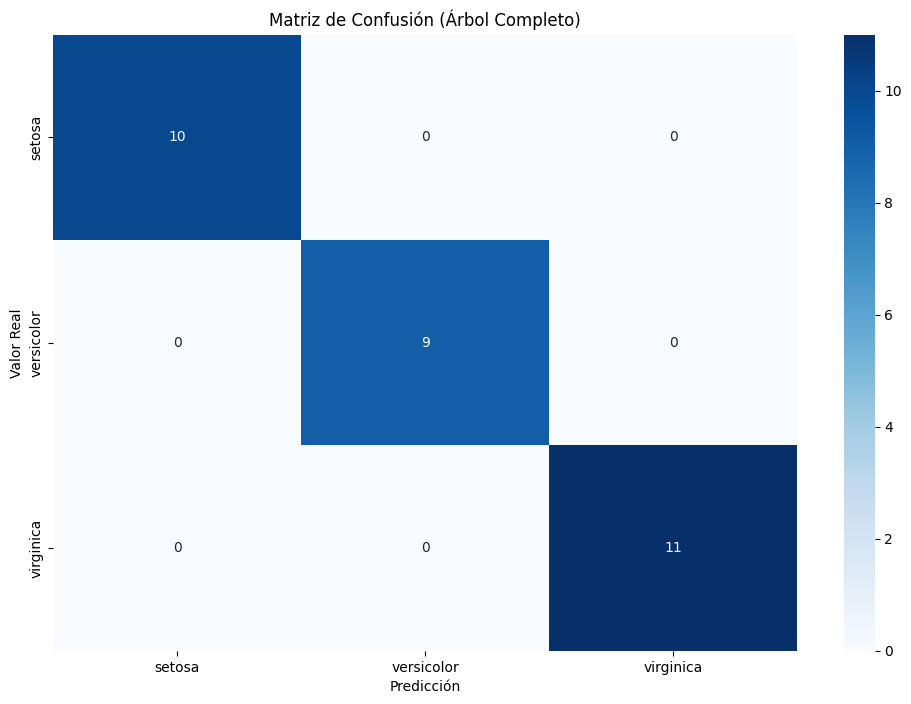

In [ ]:
# 1. Hacer predicciones sobre los datos de prueba
y_pred = tree_model.predict(X_test)

# 2. Calcular la precisión (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión (Accuracy) del modelo: {accuracy * 100:.2f}%")

# 3. Mostrar el Reporte de Clasificación (más detallado)
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 4. Mostrar la Matriz de Confusión
print("\n--- Matriz de Confusión ---")
cm = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión con Seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión (Árbol Completo)')
plt.show()

## Paso 7: ¡Visualizar el Árbol de Decisión!

Esta es la principal ventaja del algoritmo. Usamos **`plot_tree`** para crear un diagrama de flujo visual de TODAS las reglas que el modelo aprendió.



* **`feature_names`:** Le dice al gráfico cómo llamar a las características (ej. "petal width").
* **`class_names`:** Le dice al gráfico cómo llamar a las clases (ej. "setosa").
* **`filled=True`:** Colorea los nodos según la clase mayoritaria.

Visualizando el árbol de decisión completo....


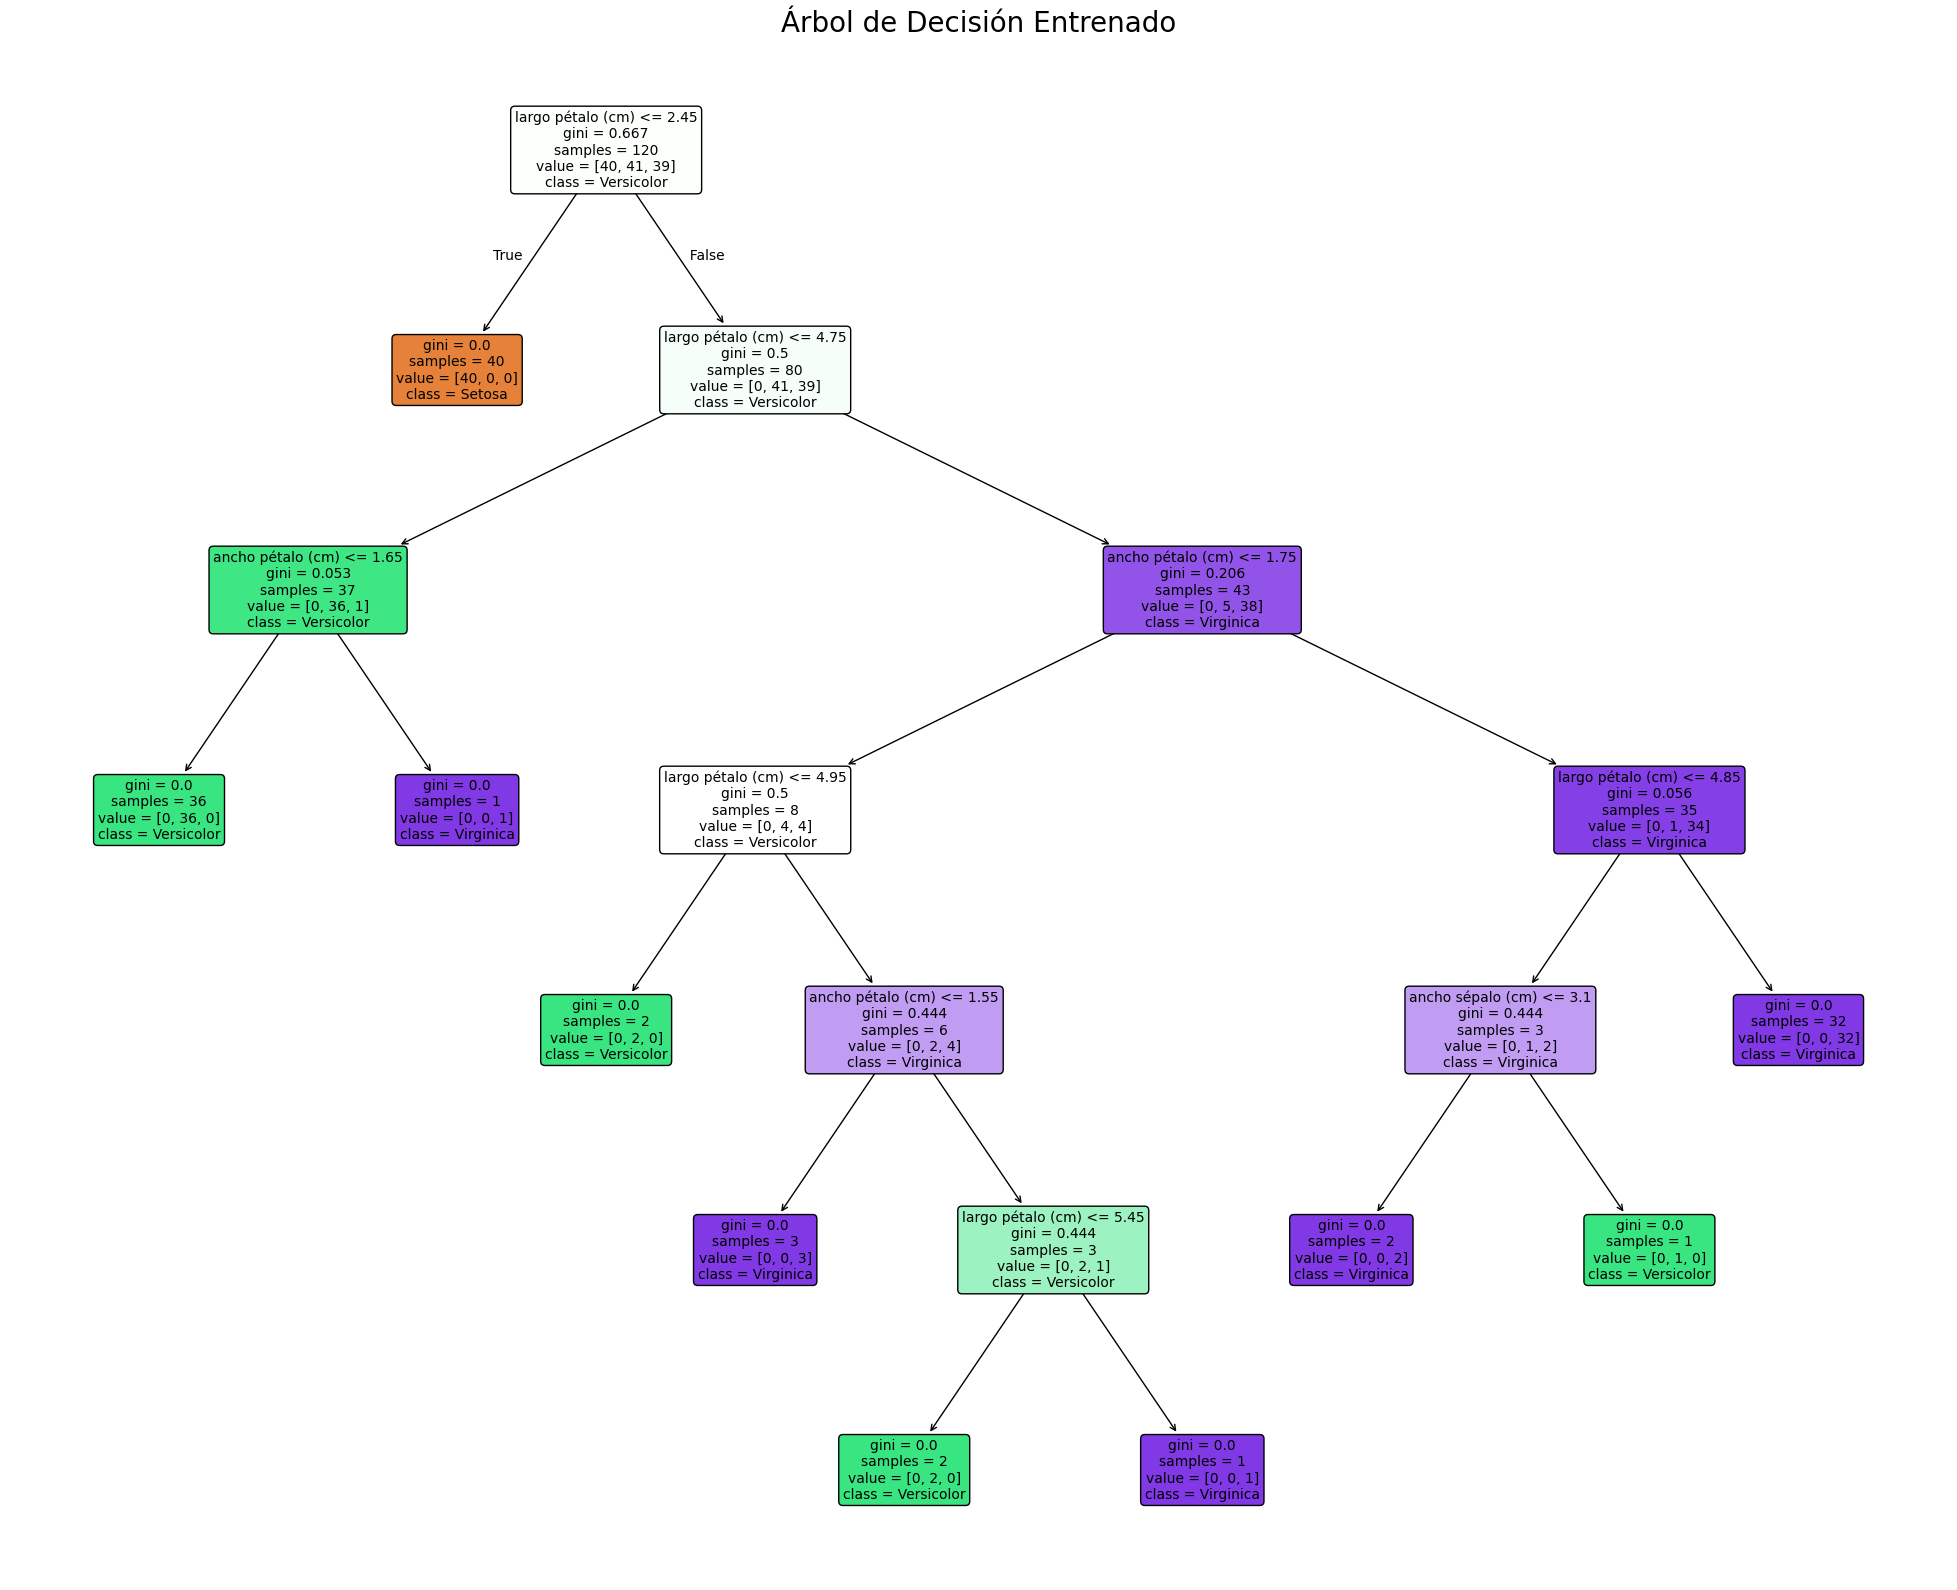

In [ ]:
# 1. Crear las listas con los nombres
nombres_caracteristicas_es = [
    'largo sépalo (cm)',
    'ancho sépalo (cm)',
    'largo pétalo (cm)',
    'ancho pétalo (cm)'
]

nombres_clases_es = ['Setosa', 'Versicolor', 'Virginica']

# 2. Visualizar el árbol de decisión completo (sin podar)
print("Visualizando el árbol de decisión completo....")

plt.figure(figsize=(25, 20))
plot_tree(tree_model,
          feature_names=nombres_caracteristicas_es,
          class_names=nombres_clases_es,
          filled=True,         # Rellenar nodos con colores
          rounded=True,        # Bordes redondeados
          fontsize=10)         # Tamaño de fuente

plt.title("Árbol de Decisión Entrenado", fontsize=20)
plt.show()

## Paso 8: Mejorar el Árbol (Poda o "Pruning")

¿Viste qué tan grande y complejo es el árbol anterior? Eso es un signo de **sobreajuste (overfitting)**. El árbol se "aprendió de memoria" los datos de entrenamiento.



Vamos a crear un modelo más simple y (probablemente) mejor. Haremos esto "podando" (pruning) el árbol, diciéndole que no crezca más allá de una profundidad máxima (**`max_depth=3`**).

In [ ]:
# 1. Crear un nuevo modelo de arbol podado
pruned_tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. Entrenarlo
pruned_tree_model.fit(X_train, y_train)

print("¡Modelo de Árbol de Decisión PODADO (max_depth=3) entrenado!")

¡Modelo de Árbol de Decisión PODADO (max_depth=3) entrenado!


## Paso 9: Visualizar y Evaluar el Árbol Podado

Ahora visualicemos este nuevo árbol. Verás que es mucho más pequeño y fácil de interpretar.



Luego, comprobaremos si este modelo más simple sigue siendo igual de preciso con los datos de prueba.

Visualizando el árbol podado (max_depth=3) en Español...


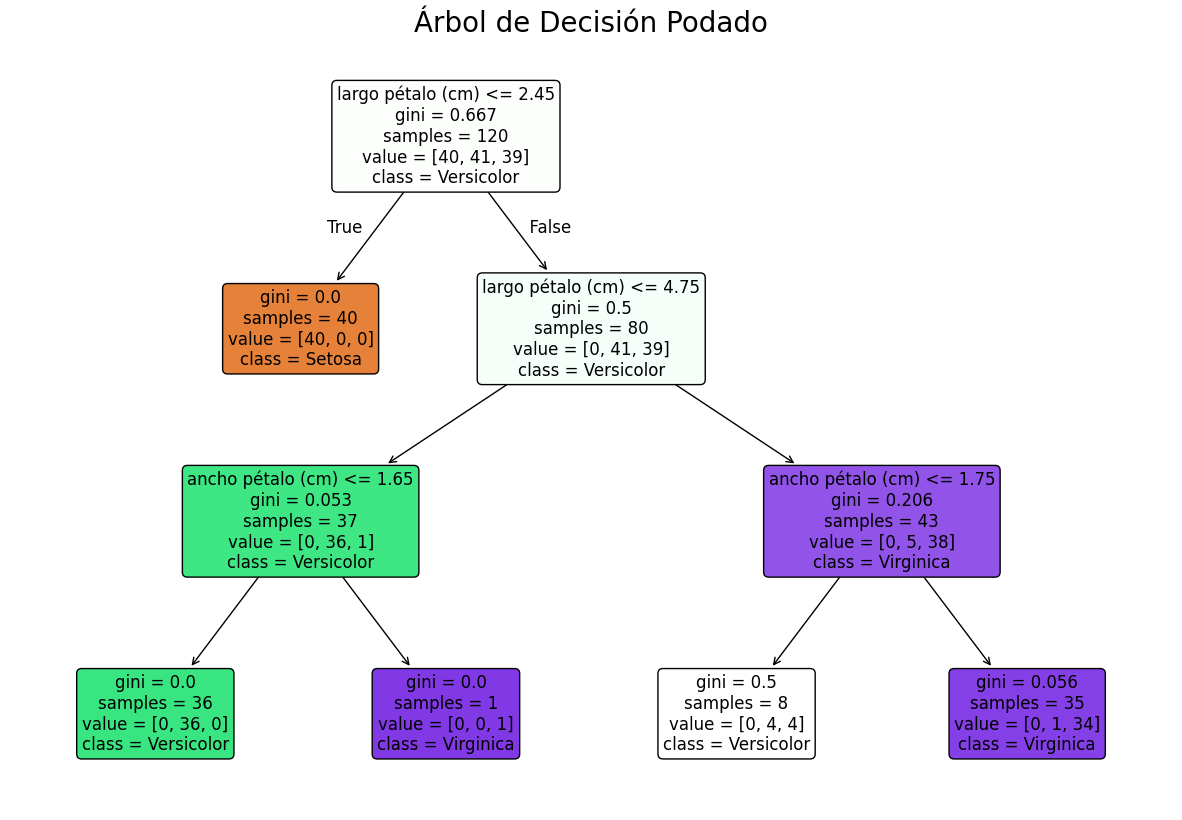


--- Comparación de Precisión ---
Precisión del ÁRBOL COMPLETO (Paso 6): 100.00%
Precisión del ÁRBOL PODADO (Paso 9): 100.00%

Reporte de Clasificación (Árbol Podado):
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
# 1. Visualizar el nuevo árbol podado
print("Visualizando el árbol podado (max_depth=3) en Español...")

plt.figure(figsize=(15, 10))
plot_tree(pruned_tree_model,
          feature_names=nombres_caracteristicas_es,
          class_names=nombres_clases_es,
          filled=True,
          rounded=True,
          fontsize=12)

plt.title("Árbol de Decisión Podado", fontsize=20)
plt.show()


# 2. Evaluar el modelo podado
y_pred_pruned = pruned_tree_model.predict(X_test)
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)

# Recuperamos la precisión del modelo anterior para comparar
try:
    accuracy_full = accuracy_score(y_test, y_pred) # y_pred fue del 'tree_model'
except NameError:
    # En caso de que la celda anterior no se haya ejecutado, recalculamos
    y_pred_full = tree_model.predict(X_test)
    accuracy_full = accuracy_score(y_test, y_pred_full)


print("\n--- Comparación de Precisión ---")
print(f"Precisión del ÁRBOL COMPLETO (Paso 6): {accuracy_full * 100:.2f}%")
print(f"Precisión del ÁRBOL PODADO (Paso 9): {accuracy_pruned * 100:.2f}%")

print("\nReporte de Clasificación (Árbol Podado):")
print(classification_report(y_test, y_pred_pruned, target_names=nombres_clases_es))




## 3. Análisis: Lo que Identificamos en Nuestros Dos Árboles

Aquí es donde conectamos la teoría con lo que vimos.

### Árbol 1: El Árbol Completo (Sin Podar)

* **Lo que identificamos:** Un árbol enorme, profundo y muy complejo. Si lo miras de cerca, tiene nodos hoja con `samples = 1` o `samples = 2`.
* **Lo que significa:** Este árbol hizo preguntas tan específicas que terminó creando reglas para cada flor individual en los datos de entrenamiento.
* **El Problema:** Esto se llama **Sobreajuste (Overfitting)**. El árbol no aprendió las reglas *generales* de cómo es una "Virginica"; se "aprendió de memoria" las 120 flores de entrenamiento.
* **La Consecuencia:** Si le das una flor nueva que es ligeramente diferente a las que "memorizó", es probable que falle. Es como un estudiante que memoriza las respuestas del examen de práctica pero no entiende el tema; si la pregunta en el examen real cambia un poco, no sabe qué hacer.



### Árbol 2: El Árbol Podado (max\_depth = 3)

* **Lo que identificamos:** Un árbol pequeño, simple e interpretable. Se detiene después de 3 niveles de preguntas, incluso si los nodos hoja no son 100% puros (verás que algunos tienen Gini > 0.0).
* **Lo que significa:** Forzamos al modelo a "rendirse" pronto. Lo obligamos a usar solo las 3 preguntas más importantes y *generales* que separan los datos.
* **La Ventaja:** Este modelo **generaliza** mucho mejor. Aprendió las reglas clave (ej. "las Setosas tienen pétalos cortos" y "las Virginicas suelen tener pétalos anchos") sin obsesionarse con las excepciones.
* **La Consecuencia:** Este modelo es mucho más **robusto** y confiable. Es el estudiante que entendió los conceptos clave. Como vimos, este modelo simple logró la misma precisión (100%) en los datos de prueba, lo que nos dice que esas 3 primeras preguntas eran más que suficientes.